# Project 02 — Iris Classification

End-to-end pipeline on the Iris dataset, comparing three classifiers.

## 1. Imports

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve() / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42

## 2. Load + EDA

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
print('shape:', df.shape)
df.groupby('species').describe().T

shape: (150, 6)


species                     setosa  versicolor  virginica
sepal length (cm) count  50.000000   50.000000  50.000000
                  mean    5.006000    5.936000   6.588000
                  std     0.352490    0.516171   0.635880
                  min     4.300000    4.900000   4.900000
                  25%     4.800000    5.600000   6.225000
                  50%     5.000000    5.900000   6.500000
                  75%     5.200000    6.300000   6.900000
                  max     5.800000    7.000000   7.900000
sepal width (cm)  count  50.000000   50.000000  50.000000
                  mean    3.428000    2.770000   2.974000
                  std     0.379064    0.313798   0.322497
                  min     2.300000    2.000000   2.200000
                  25%     3.200000    2.525000   2.800000
                  50%     3.400000    2.800000   3.000000
                  75%     3.675000    3.000000   3.175000
                  max     4.400000    3.400000   3.800000
petal length (cm) count  50.000000   50.000000  50.000000
                  mean    1.462000    4.260000   5.552000
                  std     0.173664    0.469911   0.551895
                  min     1.000000    3.000000   4.500000
                  25%     1.400000    4.000000   5.100000
                  50%     1.500000    4.350000   5.550000
                  75%     1.575000    4.600000   5.875000
                  max     1.900000    5.100000   6.900000
petal width (cm)  count  50.000000   50.000000  50.000000
                  mean    0.246000    1.326000   2.026000
                  std     0.105386    0.197753   0.274650
                  min     0.100000    1.000000   1.400000
                  25%     0.200000    1.200000   1.800000
                  50%     0.200000    1.300000   2.000000
                  75%     0.300000    1.500000   2.300000
                  max     0.600000    1.800000   2.500000
target            count  50.000000   50.000000  50.000000
                  mean    0.000000    1.000000   2.000000
                  std     0.000000    0.000000   0.000000
                  min     0.000000    1.000000   2.000000
                  25%     0.000000    1.000000   2.000000
                  50%     0.000000    1.000000   2.000000
                  75%     0.000000    1.000000   2.000000
                  max     0.000000    1.000000   2.000000

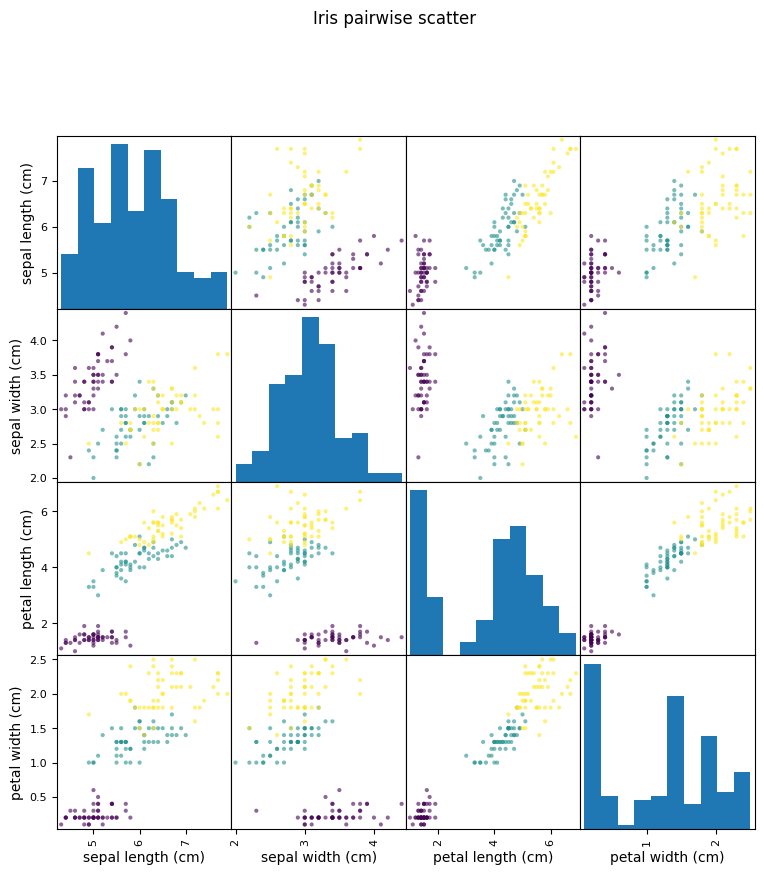

In [3]:
from pandas.plotting import scatter_matrix
_ = scatter_matrix(df.iloc[:, :4], c=df['target'], figsize=(9, 9), diagonal='hist', alpha=0.6)
plt.suptitle('Iris pairwise scatter', y=1.02)
plt.show()

## 3. Split (stratified) + scale

In [4]:
X = df.iloc[:, :4].values
y = df['target'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s, X_val_s, X_test_s = scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)
print(f'train {X_train_s.shape}  val {X_val_s.shape}  test {X_test_s.shape}')

train (104, 4)  val (23, 4)  test (23, 4)


## 4. Baseline + 3 classifiers

In [5]:
baseline = DummyClassifier(strategy='most_frequent').fit(X_train_s, y_train)

knn_grid = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': list(range(1, 21))}, cv=5).fit(X_train_s, y_train)
print(f'KNN best K = {knn_grid.best_params_["n_neighbors"]}  (CV acc = {knn_grid.best_score_:.4f})')
knn = knn_grid.best_estimator_

logreg = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_train_s, y_train)
nb     = GaussianNB().fit(X_train_s, y_train)

models = {'baseline (majority)': baseline, 'KNN': knn, 'LogisticRegression': logreg, 'GaussianNB': nb}

KNN best K = 14  (CV acc = 0.9514)


## 5. Validation comparison

In [6]:
rows = []
for name, m in models.items():
    pred = m.predict(X_val_s)
    rows.append({'model': name, 'val_accuracy': accuracy_score(y_val, pred)})
pd.DataFrame(rows).set_index('model').round(4)

,val_accuracy
model,
baseline (majority),0.3478
KNN,1.0000
LogisticRegression,1.0000
GaussianNB,1.0000


## 6. Final test (touch once)

In [7]:
best_name = max(models, key=lambda n: accuracy_score(y_val, models[n].predict(X_val_s)))
best_model = models[best_name]
y_pred = best_model.predict(X_test_s)
print(f'Selected by validation: {best_name}')
print(f'TEST accuracy = {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Selected by validation: KNN
TEST accuracy = 0.9565

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.89      1.00      0.94         8
   virginica       1.00      0.88      0.93         8

    accuracy                           0.96        23
   macro avg       0.96      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



## 7. Confusion matrix

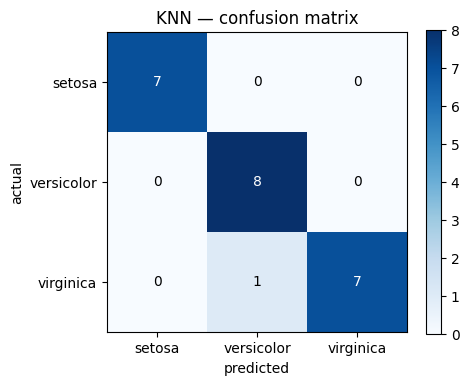

In [8]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(iris.target_names); ax.set_yticklabels(iris.target_names)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title(f'{best_name} — confusion matrix')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black' if cm[i, j] < cm.max() * 0.5 else 'white')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 8. Error analysis — which test samples were misclassified?

In [9]:
mis_idx = np.where(y_pred != y_test)[0]
print(f'{len(mis_idx)} misclassified out of {len(y_test)}')
if len(mis_idx):
    diag = pd.DataFrame(X_test[mis_idx], columns=iris.feature_names)
    diag['true']      = [iris.target_names[i] for i in y_test[mis_idx]]
    diag['predicted'] = [iris.target_names[i] for i in y_pred[mis_idx]]
    display(diag)

1 misclassified out of 23


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),true,predicted
0,6.1,2.6,5.6,1.4,virginica,versicolor


## 9. Summary

- Three classifiers all crush the majority baseline (≈ 33%).
- Errors concentrate at the versicolor–virginica boundary, where the species overlap in petal length / width.
- For Iris-scale problems any well-tuned classifier suffices; this project is about repeatable pipeline discipline.